<a href="https://colab.research.google.com/github/mohamedshehada/Prediction-of-Product-Sales/blob/main/Retail_Sales_Prediction_Part07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Sales Prediction
**Author:** Mohamed Shehada

> Analyzing product and outlet factors that influence sales using the Big Mart dataset.

---
## 1. Data Loading & Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 100)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
f_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week05/Data/sales_predictions_2023.csv"
df = pd.read_csv(f_path)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check for duplicates and missing values
print("Duplicates:", df.duplicated().sum())
print()
print(df.isnull().sum())

Duplicates: 0

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [ ]:
# Fix inconsistent categories in Item_Fat_Content
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular",
})
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


---
## 2. Exploratory Data Analysis

In [ ]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


# TO DO: add the new print statements from explore_categorical
def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes


In [ ]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4),
                           ):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

### Univariate Analysis

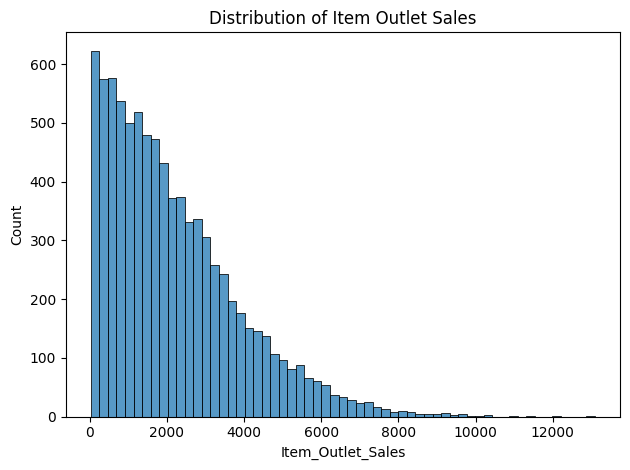

In [ ]:
# Histogram
sns.histplot(data=df, x='Item_Outlet_Sales')
plt.title('Distribution of Item Outlet Sales')
plt.tight_layout()
plt.savefig('histogram.png', dpi=300)


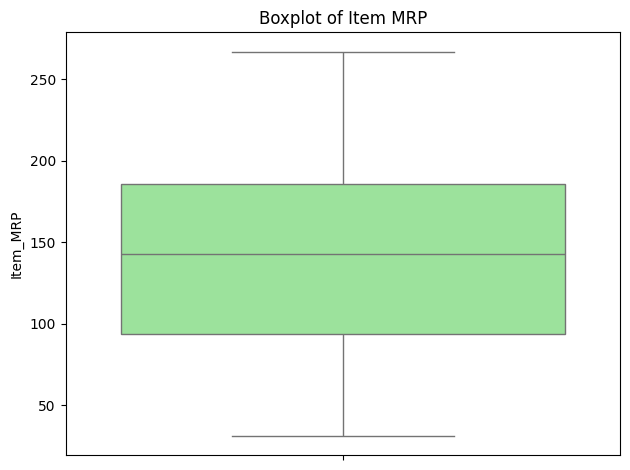

In [ ]:
# Boxplot
sns.boxplot(data=df, y='Item_MRP', color='lightgreen')
plt.title('Boxplot of Item MRP')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=300)

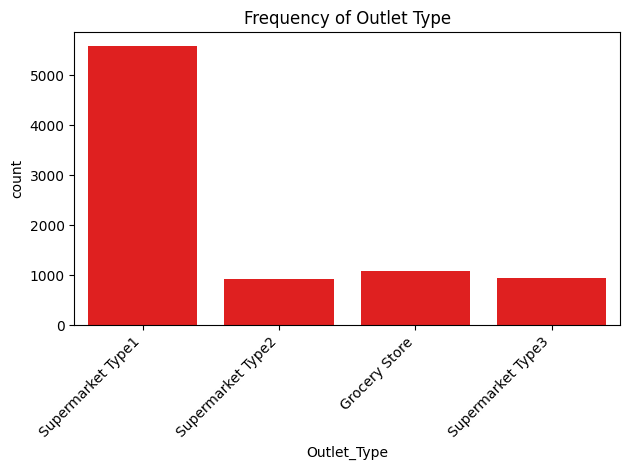

In [ ]:
# Countplot
sns.countplot(data=df, x='Outlet_Type', color='red')
plt.xticks(rotation=45, ha='right')
plt.title('Frequency of Outlet Type')
plt.tight_layout()
plt.savefig('countplot.png', dpi=300)

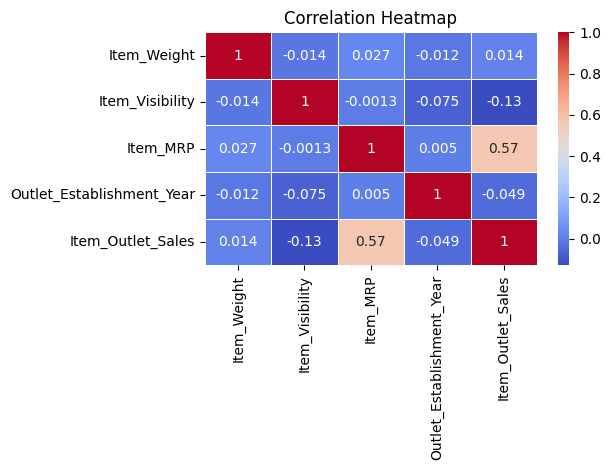

In [ ]:
# Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)

### Feature vs. Target Analysis

/tmp/ipykernel_3043/3897981250.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Location_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>)

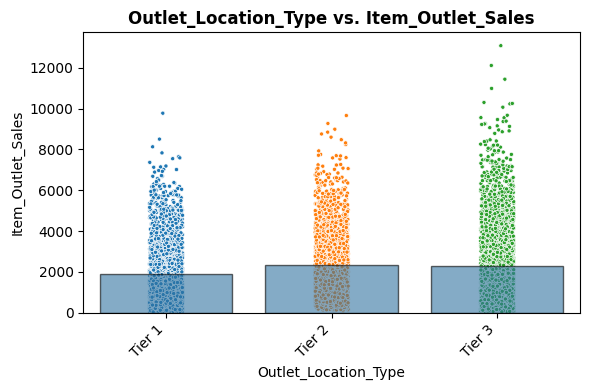

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, x='Outlet_Location_Type', order=['Tier 1', 'Tier 2', 'Tier 3'])

---
## 3. Preprocessing Pipeline

In [ ]:
# Define features and target
y = df["Item_Outlet_Sales"]
X = df.drop(columns=["Item_Outlet_Sales", "Item_Identifier"])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (6392, 10) | X_test: (2131, 10)


In [ ]:
# Numeric pipeline
num_cols = X_train.select_dtypes(include="number").columns
num_pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
num_tuple = ("numeric", num_pipe, num_cols)

# Ordinal pipeline
ord_cols = ["Outlet_Size", "Outlet_Location_Type"]
outlet_size_order     = ["Missing", "Small", "Medium", "High"]
outlet_location_order = ["Tier 1", "Tier 2", "Tier 3"]
ord_pipe = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Missing"),
    OrdinalEncoder(categories=[outlet_size_order, outlet_location_order]),
    StandardScaler()
)
ord_tuple = ("ordinal", ord_pipe, ord_cols)

# OHE pipeline
ohe_cols = X_train.select_dtypes("object").drop(columns=ord_cols).columns
ohe_pipe = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="NA"),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)
ohe_tuple = ("categorical", ohe_pipe, ohe_cols)

# ColumnTransformer
preprocessor = ColumnTransformer(
    [num_tuple, ord_tuple, ohe_tuple],
    verbose_feature_names_out=False
)
print("Preprocessor ready.")

Preprocessor ready.


---
## 4. Modeling (CRISP-DM Phase 4)

In [ ]:
def regression_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    mae       = mean_absolute_error(y_true, y_pred)
    mse       = mean_squared_error(y_true, y_pred)
    rmse      = np.sqrt(mse)
    r_squared = r2_score(y_true, y_pred)
    if verbose:
        header = "-" * 60
        print(header, f"Regression Metrics: {label}", header, sep='\n')
        print(f"- MAE  = {mae:,.3f}")
        print(f"- MSE  = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2  = {r_squared:,.3f}")
    if output_dict:
        return {'Label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R^2': r_squared}

def evaluate_regression(reg, X_train, y_train, X_test, y_test,
                        verbose=True, output_frame=False):
    y_train_pred = reg.predict(X_train)
    results_train = regression_metrics(y_train, y_train_pred, verbose=verbose,
                                       output_dict=output_frame, label='Training Data')
    print()
    y_test_pred = reg.predict(X_test)
    results_test = regression_metrics(y_test, y_test_pred, verbose=verbose,
                                      output_dict=output_frame, label='Test Data')
    if output_frame:
        results_df = pd.DataFrame([results_train, results_test])
        results_df = results_df.set_index('Label')
        results_df.index.name = None
        return results_df.round(3)

### Task 1: Linear Regression

In [ ]:
## Make and fit model
linreg_pipe = make_pipeline(preprocessor,LinearRegression())
linreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=...
                                                   'Outlet_Location_Type']),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [ ]:
results = evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test, output_frame=True)
results

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 847.129
- MSE  = 1,297,558.136
- RMSE = 1,139.104
- R^2  = 0.562

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 804.120
- MSE  = 1,194,349.715
- RMSE = 1,092.863
- R^2  = 0.567


,MAE,MSE,RMSE,R^2
Training Data,847.129,1297558.136,1139.104,0.562
Test Data,804.120,1194349.715,1092.863,0.567


**Overfitting / Underfitting Analysis:**

The Linear Regression model shows very similar R² on both training (0.562) and test (0.567) — a gap of only **0.005**, meaning there is **no overfitting**. However, both values are relatively low, indicating the model is **underfitting**: it cannot capture the non-linear relationships in this dataset.

### Task 2: Random Forest — Default Parameters

In [ ]:
# Instantiate default random forest model
rf = RandomForestRegressor(random_state = 42)
# Model Pipeline
rf_pipe = make_pipeline(preprocessor, rf)

In [ ]:
# Fit the model pipeline on the training data only
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=...
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
# Use custom function to evaluate default model
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)


------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 295.852
- MSE  = 182,433.517
- RMSE = 427.122
- R^2  = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 767.459
- MSE  = 1,218,528.339
- RMSE = 1,103.870
- R^2  = 0.558


**Overfitting / Underfitting Analysis:**

The default Random Forest shows Training R² = **0.938** vs. Test R² = **0.558** — a gap of **0.380**. This is a clear sign of **severe overfitting**: the model memorized training data instead of learning generalizable patterns, because trees grow without any depth limit by default.

**Comparison with Linear Regression:** Despite the overfitting, the default RF test score (0.558) is slightly lower than Linear Regression (0.567). Linear Regression performs marginally better at this stage.

### Task 3: Tuned Random Forest — GridSearchCV

In [ ]:
# Define param grid with options to try
params = {
    'randomforestregressor__max_depth':        [8, 10, 12],
    'randomforestregressor__n_estimators':     [200, 300, 400],
    'randomforestregressor__min_samples_leaf': [3, 4, 5],
    'randomforestregressor__max_features':     ['sqrt', 0.4, 0.5]
}

In [ ]:
# Instantiate the gridsearch
gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv = 3, verbose=1)
# Fit the gridsearch on training data
gridsearch.fit(X_train, y_train)


Fitting 3 folds for each of 81 candidates, totalling 243 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimpute...
                                                                         Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [8, 10, 12],
                         'randomforestregressor__max_features': ['sqrt', 0.4,
                                                                 0.5],
                         'randomforestregressor__min_samples_leaf': [3, 4, 5],
                         'randomforestregressor__n_estimators': [200, 300,
                                                                 400]},
             verbose=1)

In [ ]:
# Obtain best parameters
gridsearch.best_params_

{'randomforestregressor__max_depth': 8,
 'randomforestregressor__max_features': 0.5,
 'randomforestregressor__min_samples_leaf': 5,
 'randomforestregressor__n_estimators': 400}

In [ ]:
# Define and refit best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 722.382
- MSE  = 1,055,990.560
- RMSE = 1,027.614
- R^2  = 0.643

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 725.887
- MSE  = 1,086,997.600
- RMSE = 1,042.592
- R^2  = 0.606


**Tuned vs. Default Random Forest:**

After GridSearchCV (best params: max_depth=8, n_estimators=400, min_samples_leaf=5, max_features=0.5), the tuned model shows Training R² = **0.643** vs. Test R² = **0.606** — a gap of only **0.037**. This is a dramatic improvement over the default RF gap of 0.380, meaning hyperparameter tuning successfully reduced overfitting.

---
## 5. Evaluation (CRISP-DM Phase 5)

### Recommended Model: Tuned Random Forest

Based on all experiments, the **Tuned Random Forest** is the recommended model. It achieves the best balance between accuracy and generalization:

The tuned model significantly reduces overfitting while achieving the best test performance of all three models.

**R² Interpretation for Stakeholders:**

Our model's Test R² is **0.606**, meaning it explains about **61% of the variation in product sales**. In simple terms: if you are trying to understand why one product sells more than another across different outlets, our model can correctly account for about 6 out of every 10 factors driving that difference.

**Selected Metric: RMSE**

On average, the model's predictions are off by approximately **$1,042**. We chose RMSE because it is expressed in the same unit as sales — dollars — making it easy to communicate to any stakeholder without requiring technical knowledge.

RMSE is the only metric that directly carries the same unit as the target variable, making it the most intuitive choice for business reporting.

**Overfitting Assessment — Tuned Random Forest:**

Training R² = **0.643** vs. Test R² = **0.606** — a gap of only **0.037**.

This is an excellent result: the model generalizes well to unseen data. Compared to the default Random Forest (gap of 0.380), hyperparameter tuning dramatically improved reliability and reduced overfitting.